# Task 5: Interactive Business Dashboard in Streamlit

## Problem Statement

Businesses require interactive dashboards to monitor sales performance, profit, and customer behavior. Business Intelligence dashboards help organizations make data-driven decisions using visual insights.

## Objective

The objective of this project is to build an interactive Streamlit dashboard that analyzes sales, profit, and customer performance using the Global Superstore dataset.


## Import Required Libraries

In [108]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

## Load Dataset

In [109]:
df = pd.read_csv("Global_Superstore.csv")

In [110]:
df.shape

(51290, 27)

In [111]:
df.columns

Index(['Category', 'City', 'Country', 'Customer ID', 'Customer Name',
       'Discount', 'Market', 'ji_lu-shu', 'Order Date', 'Order ID',
       'Order Priority', 'Product ID', 'Product Name', 'Profit', 'Quantity',
       'Region', 'Row ID', 'Sales', 'Segment', 'Ship Date', 'Ship Mode',
       'Shipping Cost', 'State', 'Sub-Category', 'Year', 'Market2', 'weeknum'],
      dtype='object')

In [112]:
df.head()

,Category,City,Country,Customer ID,Customer Name,Discount,Market,ji_lu-shu,Order Date,Order ID,...,Sales,Segment,Ship Date,Ship Mode,Shipping Cost,State,Sub-Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,00:00.0,CA-2011-130813,...,19,Consumer,00:00.0,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,00:00.0,CA-2011-148614,...,19,Consumer,00:00.0,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,00:00.0,CA-2011-118962,...,21,Consumer,00:00.0,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,00:00.0,CA-2011-118962,...,111,Consumer,00:00.0,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,00:00.0,CA-2011-146969,...,6,Consumer,00:00.0,Standard Class,1.32,California,Paper,2011,North America,40


## Explore Dataset

In [113]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Category        51290 non-null  object 
 1   City            51290 non-null  object 
 2   Country         51290 non-null  object 
 3   Customer ID     51290 non-null  object 
 4   Customer Name   51290 non-null  object 
 5   Discount        51290 non-null  float64
 6   Market          51290 non-null  object 
 7   ji_lu-shu       51290 non-null  int64  
 8   Order Date      51290 non-null  object 
 9   Order ID        51290 non-null  object 
 10  Order Priority  51290 non-null  object 
 11  Product ID      51290 non-null  object 
 12  Product Name    51290 non-null  object 
 13  Profit          51290 non-null  float64
 14  Quantity        51290 non-null  int64  
 15  Region          51290 non-null  object 
 16  Row ID          51290 non-null  int64  
 17  Sales           51290 non-null 

In [114]:
df.describe()

,Discount,ji_lu-shu,Profit,Quantity,Row ID,Sales,Shipping Cost,Year,weeknum
count,51290.000000,51290.0,51290.000000,51290.000000,51290.00000,51290.000000,51290.000000,51290.000000,51290.000000
mean,0.142908,1.0,28.610982,3.476545,25645.50000,246.498440,26.375818,2012.777208,31.287112
std,0.212280,0.0,174.340972,2.278766,14806.29199,487.567175,57.296810,1.098931,14.429795
min,0.000000,1.0,-6599.978000,1.000000,1.00000,0.000000,0.002000,2011.000000,1.000000
25%,0.000000,1.0,0.000000,2.000000,12823.25000,31.000000,2.610000,2012.000000,20.000000
50%,0.000000,1.0,9.240000,3.000000,25645.50000,85.000000,7.790000,2013.000000,33.000000
75%,0.200000,1.0,36.810000,5.000000,38467.75000,251.000000,24.450000,2014.000000,44.000000
max,0.850000,1.0,8399.976000,14.000000,51290.00000,22638.000000,933.570000,2014.000000,53.000000


In [115]:
df.isnull().sum()

,0
Category,0
City,0
Country,0
Customer ID,0
Customer Name,0
Discount,0
Market,0
ji_lu-shu,0
Order Date,0
Order ID,0


## Data Cleaning

In [116]:
df = df.drop_duplicates()

In [117]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [118]:
df.isnull().sum()

,0
Category,0
City,0
Country,0
Customer ID,0
Customer Name,0
Discount,0
Market,0
ji_lu-shu,0
Order Date,0
Order ID,0


## Exploratory Data Analysis (EDA)

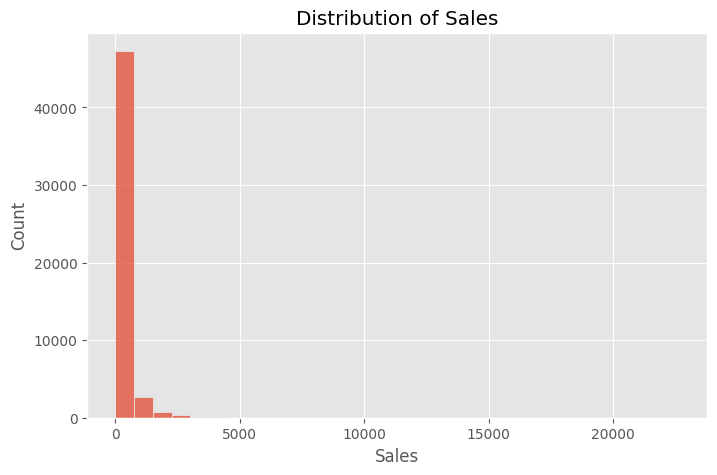

In [119]:
plt.figure(figsize=(8,5))
sns.histplot(df['Sales'], bins=30)
plt.title("Distribution of Sales")
plt.show()

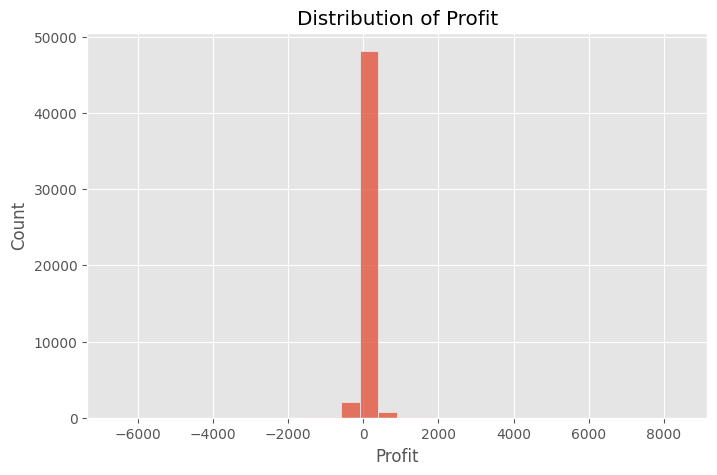

In [120]:
plt.figure(figsize=(8,5))
sns.histplot(df['Profit'], bins=30)
plt.title("Distribution of Profit")
plt.show()

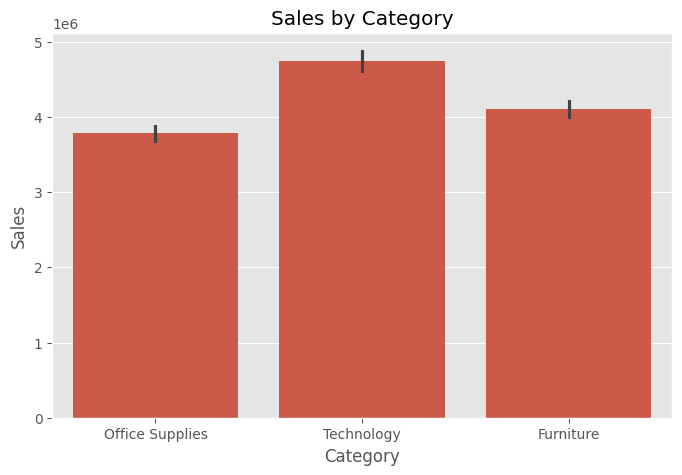

In [121]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=df,
    x='Category',
    y='Sales',
    estimator=sum
)
plt.title("Sales by Category")
plt.show()

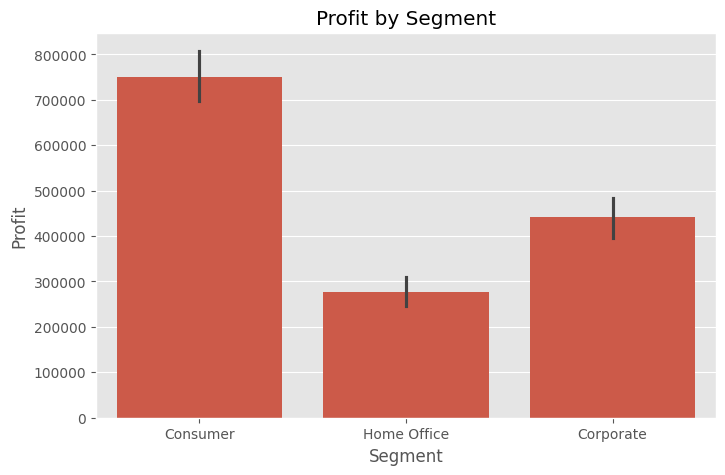

In [122]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=df,
    x='Segment',
    y='Profit',
    estimator=sum
)
plt.title("Profit by Segment")
plt.show()

## Key Performance Indicators (KPIs)

In [123]:
total_sales = df['Sales'].sum()

total_profit = df['Profit'].sum()

total_orders = df['Order ID'].nunique()

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Total Orders:", total_orders)

Total Sales: 12642905
Total Profit: 1467457.2912800002
Total Orders: 25035


## Top 5 Customers by Sales

In [124]:
top_customers = (
    df.groupby('Customer Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

top_customers

,Sales
Customer Name,
Tom Ashbrook,40489
Tamara Chand,37453
Greg Tran,35552
Christopher Conant,35187
Sean Miller,35170


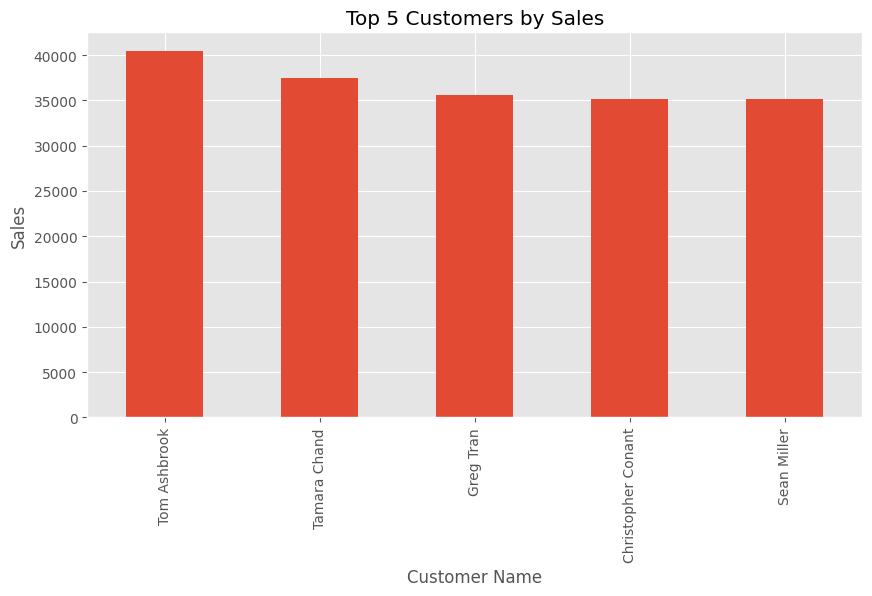

In [125]:
plt.figure(figsize=(10,5))

top_customers.plot(kind='bar')

plt.title("Top 5 Customers by Sales")

plt.xlabel("Customer Name")

plt.ylabel("Sales")

plt.show()

## Sales by Region

In [126]:
sales_region = df.groupby('Region')['Sales'].sum()

sales_region

,Sales
Region,
Africa,783776
Canada,66932
Caribbean,324281
Central,2822399
Central Asia,752839
EMEA,806184
East,678834
North,1248192
North Asia,848349


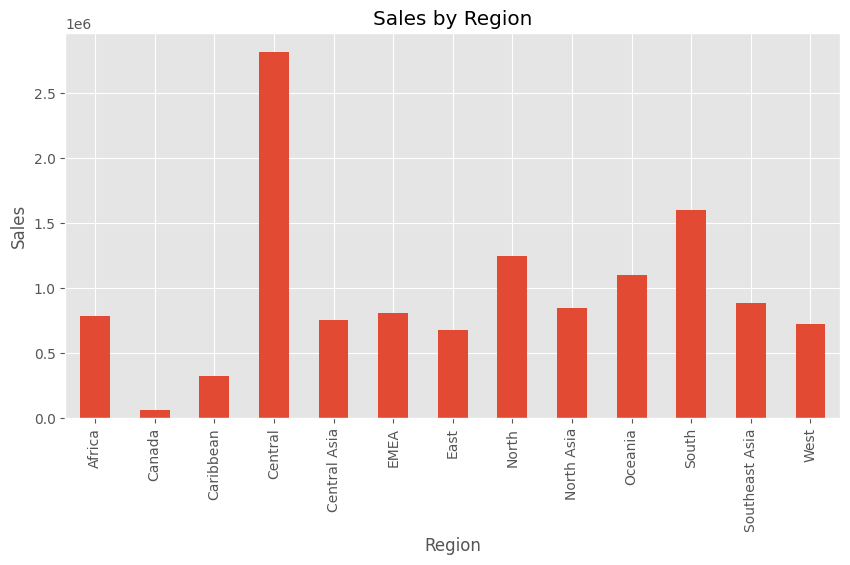

In [127]:
plt.figure(figsize=(10,5))

sales_region.plot(kind='bar')

plt.title("Sales by Region")

plt.xlabel("Region")

plt.ylabel("Sales")

plt.show()

## Profit by Category

In [128]:
profit_category = df.groupby('Category')['Profit'].sum()

profit_category

,Profit
Category,
Furniture,285204.72380
Office Supplies,518473.83430
Technology,663778.73318


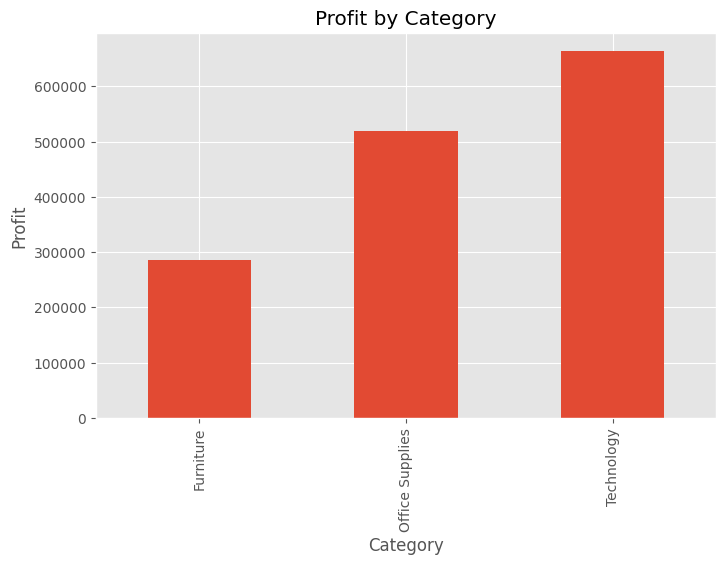

In [129]:
plt.figure(figsize=(8,5))

profit_category.plot(kind='bar')

plt.title("Profit by Category")

plt.xlabel("Category")

plt.ylabel("Profit")

plt.show()

## Insights

- The dataset contains over **51,000** sales records from different regions and markets.
- Technology and Office Supplies contribute significantly to overall sales.
- Sales performance varies across different regions.
- A small number of customers generate a large portion of total sales.
- Interactive dashboards help business users monitor KPIs and make data-driven decisions.

## Streamlit Dashboard

In [130]:
!pip install streamlit -q

In [131]:
%%writefile app.py

import streamlit as st
import pandas as pd

# Page Configuration
st.set_page_config(
    page_title="Global Superstore Dashboard",
    layout="wide"
)

# Load Dataset
df = pd.read_csv("Global_Superstore.csv")

# Convert Date Columns
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

# Dashboard Title
st.title("📊 Global Superstore Business Dashboard")

# Sidebar Filters
st.sidebar.header("Filters")

region = st.sidebar.selectbox(
    "Select Region",
    ["All"] + sorted(df["Region"].unique())
)

category = st.sidebar.selectbox(
    "Select Category",
    ["All"] + sorted(df["Category"].unique())
)

subcategory = st.sidebar.selectbox(
    "Select Sub-Category",
    ["All"] + sorted(df["Sub-Category"].unique())
)

filtered_df = df.copy()

if region != "All":
    filtered_df = filtered_df[filtered_df["Region"] == region]

if category != "All":
    filtered_df = filtered_df[filtered_df["Category"] == category]

if subcategory != "All":
    filtered_df = filtered_df[filtered_df["Sub-Category"] == subcategory]

# KPIs
total_sales = filtered_df["Sales"].sum()
total_profit = filtered_df["Profit"].sum()
total_orders = filtered_df["Order ID"].nunique()

col1, col2, col3 = st.columns(3)

col1.metric("Total Sales", f"${total_sales:,.2f}")
col2.metric("Total Profit", f"${total_profit:,.2f}")
col3.metric("Total Orders", total_orders)

# Top Customers
st.subheader("Top 5 Customers by Sales")

top_customers = (
    filtered_df.groupby("Customer Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

st.bar_chart(top_customers)

# Sales by Region
st.subheader("Sales by Region")

sales_region = (
    filtered_df.groupby("Region")["Sales"]
    .sum()
)

st.bar_chart(sales_region)

# Profit by Category
st.subheader("Profit by Category")

profit_category = (
    filtered_df.groupby("Category")["Profit"]
    .sum()
)

st.bar_chart(profit_category)

# Dataset Preview
st.subheader("Dataset Preview")
st.dataframe(filtered_df.head())

Writing app.py


In [135]:
!pkill streamlit

In [ ]:
!streamlit run app.py & npx localtunnel --port 8501

⠙⠹

⠸⠼⠴⠦⠧⠇⠏your url is: https://loose-planets-bow.loca.lt
2026-07-14 18:11:46.468 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.19.83.133:8501



In [134]:
!wget -q -O - ipv4.icanhazip.com

34.19.83.133


## Conclusion

This project demonstrates the development of an interactive Business Intelligence dashboard using Streamlit and the Global Superstore dataset.

The dashboard provides interactive filters for Region, Category, and Sub-Category while displaying important KPIs such as Total Sales, Total Profit, and Total Orders.

It also includes visualizations for the Top 5 Customers by Sales, Sales by Region, and Profit by Category, enabling users to gain meaningful business insights and make data-driven decisions.